# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
---

## Informasi Dataset: Titanic - Machine Learning from Disaster

| Atribut | Detail |
|---|---|
| **Nama Dataset** | Titanic Passenger Survival Dataset |
| **Sumber** | [Kaggle - Titanic: Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic) |
| **URL Raw Data** | https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv |
| **Jumlah Baris** | 891 penumpang |
| **Jumlah Kolom** | 12 fitur |
| **Task** | Binary Classification (Survived: 0 = Tidak Selamat, 1 = Selamat) |
| **Lisensi** | Public Domain |

### Deskripsi Dataset
Dataset ini berisi informasi penumpang kapal Titanic yang tenggelam pada 15 April 1912. Tujuan utama adalah memprediksi apakah seorang penumpang selamat atau tidak berdasarkan fitur-fitur yang tersedia.

### Deskripsi Fitur

| Kolom | Tipe | Deskripsi |
|---|---|---|
| `PassengerId` | Integer | ID unik setiap penumpang |
| `Survived` | Integer (0/1) | **Target** — 0 = tidak selamat, 1 = selamat |
| `Pclass` | Integer (1/2/3) | Kelas tiket penumpang (1 = 1st, 2 = 2nd, 3 = 3rd) |
| `Name` | String | Nama lengkap penumpang |
| `Sex` | String | Jenis kelamin penumpang (male/female) |
| `Age` | Float | Usia penumpang dalam tahun |
| `SibSp` | Integer | Jumlah saudara kandung/pasangan yang ikut |
| `Parch` | Integer | Jumlah orang tua/anak yang ikut |
| `Ticket` | String | Nomor tiket |
| `Fare` | Float | Harga tiket yang dibayarkan |
| `Cabin` | String | Nomor kabin (banyak yang kosong) |
| `Embarked` | String | Pelabuhan keberangkatan (C = Cherbourg, Q = Queenstown, S = Southampton) |

### Kondisi Data
- Kolom `Age` memiliki ~20% missing values
- Kolom `Cabin` memiliki ~77% missing values  
- Kolom `Embarked` memiliki 2 missing values
- Tidak terdapat baris duplikat



# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
# Import library dasar untuk manipulasi data
import pandas as pd
import numpy as np

# Import library untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Import library untuk Data Preprocessing dari Scikit-Learn
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer

# Pengaturan opsional untuk mempercantik visualisasi dan mengabaikan peringatan
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimpor!")

Semua library berhasil diimpor!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Jika menggunakan dataset dari Google Drive, uncomment dua baris di bawah ini:
# from google.colab import drive
# drive.mount('/content/drive')
# dataset_path = '/content/drive/MyDrive/path_ke_folder_anda/dataset.csv'

# Contoh menggunakan dataset publik (Titanic) agar kode bisa langsung dicoba
dataset_path = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# Membaca dataset menggunakan pandas
df = pd.read_csv(dataset_path)

# Mengecek beberapa baris awal dataset untuk memahami strukturnya
print("Tampilan 5 Baris Pertama Dataset:")
display(df.head())

# Memeriksa dimensi data (jumlah baris dan kolom)
print(f"\nDimensi dataset: {df.shape[0]} baris dan {df.shape[1]} kolom.")

Tampilan 5 Baris Pertama Dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Dimensi dataset: 891 baris dan 12 kolom.


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Statistik Deskriptif (Numerik):


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Jumlah Missing Values per Kolom:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


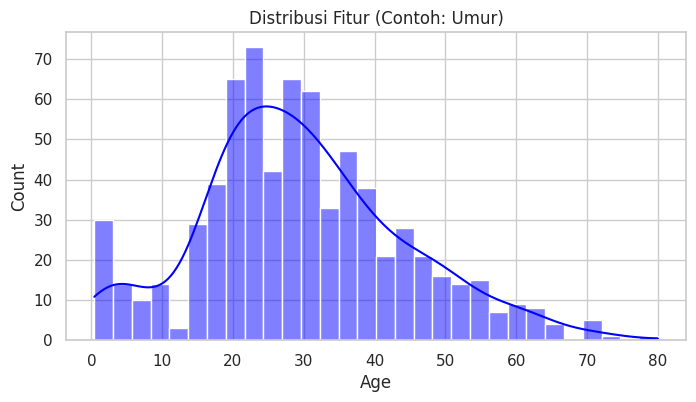

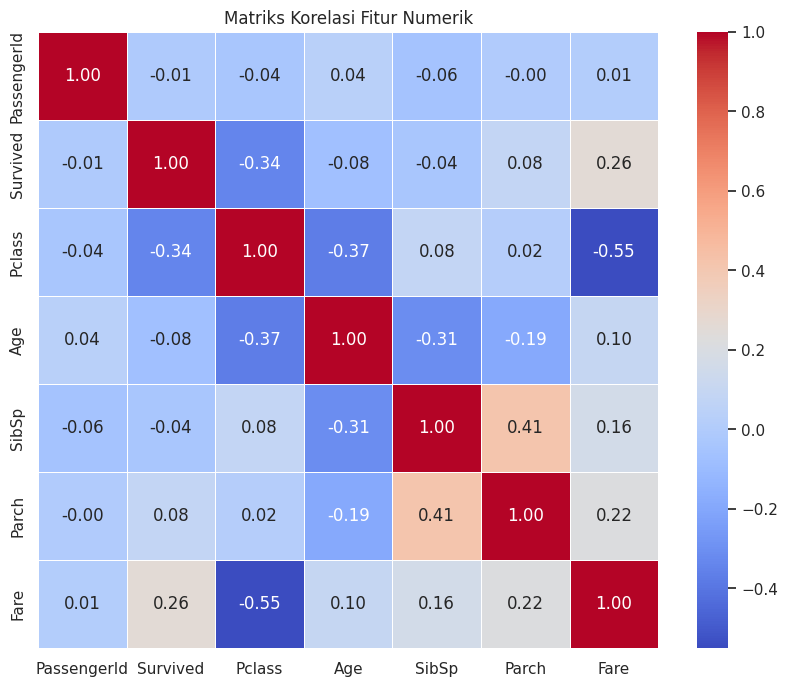

In [3]:
# 1. Melihat informasi tipe data dan jumlah nilai non-null
print("Informasi Dataset:")
df.info()

# 2. Menampilkan ringkasan statistik deskriptif untuk kolom numerik
print("\nStatistik Deskriptif (Numerik):")
display(df.describe())

# 3. Mengecek jumlah missing values (data kosong) pada setiap kolom
print("\nJumlah Missing Values per Kolom:")
print(df.isnull().sum())

# 4. Visualisasi Distribusi (Contoh menggunakan kolom 'Age' jika ada)
# Sesuaikan 'Age' dengan salah satu fitur numerik dari dataset Anda
if 'Age' in df.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df['Age'].dropna(), kde=True, bins=30, color='blue')
    plt.title('Distribusi Fitur (Contoh: Umur)')
    plt.show()

# 5. Visualisasi Matriks Korelasi (Hanya untuk fitur numerik)
# Berguna untuk melihat hubungan linier antar variabel
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriks Korelasi Fitur Numerik')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# Membuat salinan dataset agar data asli tetap utuh
df_clean = df.copy()

# 1. Menghapus Data Duplikat
jumlah_duplikat = df_clean.duplicated().sum()
print(f"Jumlah baris duplikat yang dihapus: {jumlah_duplikat}")
df_clean = df_clean.drop_duplicates()

# 2. Menangani Missing Values (Data Kosong)
# Pisahkan kolom berdasarkan tipe datanya
num_cols = df_clean.select_dtypes(include=[np.number]).columns
cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns

# Mengisi nilai kosong numerik dengan Nilai Tengah (Median)
imputer_num = SimpleImputer(strategy='median')
if len(num_cols) > 0:
    df_clean[num_cols] = imputer_num.fit_transform(df_clean[num_cols])

# Mengisi nilai kosong kategorikal dengan Modus (Nilai yang sering muncul)
imputer_cat = SimpleImputer(strategy='most_frequent')
if len(cat_cols) > 0:
    df_clean[cat_cols] = imputer_cat.fit_transform(df_clean[cat_cols])

# 3. Encoding Data Kategorikal (Mengubah teks menjadi numerik)
# Menggunakan Label Encoding untuk setiap kolom teks
le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# 4. Standarisasi Fitur
# Proses ini membuat skala data seragam (Mean = 0, Std = 1)
# PENTING: Jika ada kolom target/label (misal 'Survived' di Titanic), keluarkan dari standarisasi
target_col = 'Survived' # Silakan ubah sesuai target klasifikasi Anda nanti

# Mendapatkan kolom fitur saja (tanpa target)
features = [col for col in df_clean.columns if col != target_col]

scaler = StandardScaler()
df_clean[features] = scaler.fit_transform(df_clean[features])

def clean_data(df):
    # Masukkan logika handling missing value & duplikat di sini
    return df_cleaned

def preprocess_data(df):
    # Masukkan logika encoding & scaling di sini
    return data_ready_to_train

print("\nProses Data Preprocessing Selesai!")
print("Tampilan 5 Baris Pertama Data Bersih (Siap untuk Pemodelan):")
display(df_clean.head())

# ── Export Hasil Preprocessing ke CSV ──────────────────────────────────────
output_filename = 'cleaned_titanic.csv'
df_clean.to_csv(output_filename, index=False)
print(f"\n✅ Hasil preprocessing berhasil disimpan ke '{output_filename}'")
print(f"   Shape: {df_clean.shape[0]} baris x {df_clean.shape[1]} kolom")
print(f"   Kolom: {list(df_clean.columns)}")


Jumlah baris duplikat yang dihapus: 0

Proses Data Preprocessing Selesai!
Tampilan 5 Baris Pertama Data Bersih (Siap untuk Pemodelan):


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,-1.730108,0.0,0.827377,-1.310217,0.737695,-0.565736,0.432793,-0.473674,0.918966,-0.502445,-0.281881,0.585954
1,-1.726220,1.0,-1.566107,-0.991410,-1.355574,0.663861,0.432793,-0.473674,1.282625,0.786845,1.161545,-1.942303
2,-1.722332,1.0,0.827377,-0.357685,-1.355574,-0.258337,-0.474545,-0.473674,1.646283,-0.488854,-0.281881,0.585954
3,-1.718444,1.0,-1.566107,-0.672604,-1.355574,0.433312,0.432793,-0.473674,-1.442322,0.420730,0.057748,0.585954
4,-1.714556,0.0,0.827377,-1.671790,0.737695,0.433312,-0.474545,-0.473674,0.664904,-0.486337,-0.281881,0.585954



✅ Hasil preprocessing berhasil disimpan ke 'cleaned_titanic.csv'
   Shape: 891 baris x 12 kolom
   Kolom: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
